In [103]:
import numpy as np
import matplotlib.pyplot as plt

from numba import cfunc,carray
from numbalsoda import lsoda_sig,lsoda

In [ ]:
def make_lsoda_crossfeeding(muMatrix,kMatrix,dTensor,lVector,supplyVec,delta,Ns,Nr):
    """
    Parameters
    ----------
    muMatrix : 2D array
        uptake rates of shape (Ns,Nr) [C]
    kMatrix : 2D array
        half-saturation constants of shape (Ns,Nr) [K]
    dTensor : 3D array
        stoichiometric matrix of shape (Ns,Nr,Nr) [D]
    lVector : 1D array
        leakage fractions of shape (Ns,) [l]
    supplyVec : 1D array
        resource supply concentrations of shape (Nr,) [R]
    delta : float
        dilution rate [delta]
    Ns : int
        number of species
    Nr : int
        number of resources
    """
    @cfunc(lsoda_sig)
    def cf_dynamics_lsoda(t, x, dx, p):
        x_ = carray(x, (Ns+Nr,))
        dx_ = carray(dx, (Ns+Nr,))
        populations = x_[:Ns]
        resources = x_[Ns:]
        resources[resources<0] = 0
        populations[populations<0] = 0

        uptakeMatrix = (muMatrix.T * populations).T * resources/(kMatrix+resources)
        resourceUsage = np.sum(uptakeMatrix,axis=0)          
        leakage = np.sum(np.dot(dTensor,(uptakeMatrix.T*lVector)),axis=1) ### Assuming that the stoichiometric matrix is the same for all species. Replace with loop species if dMatrix is species-specific. Note: try not to loop over resources - computationally expensive than species since Nr>Ns usually


        dx_[:Ns] = (np.sum(uptakeMatrix,axis=1)*(1-lVector) - delta*populations )   
        dx_[Ns:] = delta*(supplyVec[:Nr] - resources) - resourceUsage + leakage

        dx_[:Ns][populations < 1e-20] = 0
        # dx_[Ns:][(dx_[Ns:]+resources) < 1e-20] = 0
        # dx_[Ns:][resources < 0] = 0
    return cf_dynamics_lsoda

def run_lsoda_crossfeeding(muMatrix,kMatrix,dTensor,lVector,delta,Ns,Nr,N0,R0,t_max):
    cf_dynamics_lsoda = make_lsoda_crossfeeding(muMatrix,kMatrix,dTensor,lVector,R0,delta,Ns,Nr)
    funcptr = cf_dynamics_lsoda.address
    initialConditions = np.concatenate((N0,R0))
    t = np.linspace(0,t_max,1000)
    
    usol, success = lsoda(funcptr, initialConditions.flatten(), t,rtol=1e-8, atol=1e-8)

    return usol, success

In [105]:
Ns = 1
Nr = 50

In [106]:
muMatrix = np.random.lognormal(-1,1,(Ns,Nr))
kMatrix = np.random.lognormal(-5,2,(Ns,Nr))
dTensor = np.random.uniform(0,1/(Nr-1),(Nr,Nr))
np.fill_diagonal(dTensor,0)
lVector = np.random.uniform(0,0.5,(Ns,))

In [107]:
print(np.mean(muMatrix),np.std(muMatrix))
print(np.mean(kMatrix),np.std(kMatrix),np.min(kMatrix),np.max(kMatrix))

0.6010126049881448 0.8003024950187269
0.02357464065637356 0.052325686364561176 3.70761227287613e-05 0.30630298633670766


In [108]:
delta = 0
supplyVec = np.ones(Nr)*10
initialPopulations = np.ones(Ns)*0.1
initialConditions = np.concatenate((initialPopulations,supplyVec))
t = np.linspace(0,1000,1000)

In [109]:
cf_dynamics_lsoda = make_lsoda_crossfeeding(muMatrix,kMatrix,dTensor,lVector,supplyVec,delta,Ns,Nr)
funcptr = cf_dynamics_lsoda.address
usol, success = lsoda(funcptr, initialConditions.flatten(), t,rtol=1e-10, atol=1e-10)
print(success)

False


[lsoda] 10000 steps taken before reaching tout


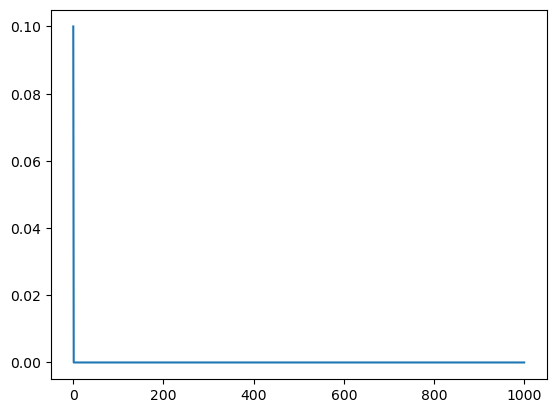

In [110]:
plt.plot(t,usol[:,:Ns])
plt.show()

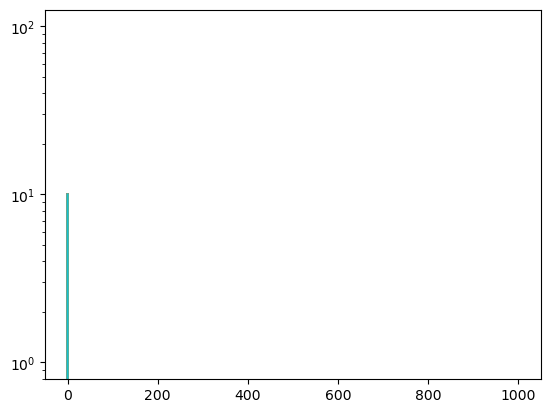

In [111]:
plt.plot(t, usol[:, Ns:])
plt.yscale('log')

In [112]:
usol[:,Ns:].min(), 

(np.float64(0.0),)

In [113]:
usol[:,Ns:].min()

np.float64(0.0)